# Final Project 

## Algal Bloom Predictability Through Machine Learning 

### Ava Ghannam and Mia Geudtner

## Step 1. Import libraries

This project uses Python libraries for data handling, visualization, machine learning, and model interpretation. Pandas and NumPy are used for data preparation, Matplotlib is used for visualization, Scikit-learn is used to build the classification model, and SHAP is used to explain how environmental variables influence bloom predictions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2. Load the dataset

The dataset contains weekly environmental observations along with Karenia brevis concentrations. These variables represent nutrient conditions, hydrology, and water properties that may influence harmful algal bloom occurrence.

In [3]:
df = pd.read_csv("data_weekly_intepolated(in) (1).csv")
df.head()

,time,kb,zos,salinity,water_temp,wind_direction,wind_speed,peace_discharge,peace_TN,peace_TP
0,1/4/1993,333,0.012906,33.043478,26.8,36.0,13.9,202.0,8.2000,1.999091
1,1/11/1993,667,0.015614,33.065217,27.0,118.0,16.2,423.0,10.1000,1.934545
2,1/18/1993,667,0.021702,33.086957,27.1,108.0,16.2,1470.0,12.0000,1.870000
3,1/25/1993,0,0.015950,33.108696,26.8,110.0,12.6,1450.0,10.0475,1.870500
4,2/1/1993,0,0.008977,33.130435,26.5,14.0,17.5,1490.0,8.0950,1.871000


## Step 3. Inspect the dataset

Before modeling, the dataset was inspected to confirm the available variables, data types, and overall structure. This step helps verify that the data are suitable for machine learning and identifies whether additional cleaning is needed.

In [4]:
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 1617 entries, 0 to 1616
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             1617 non-null   str    
 1   kb               1617 non-null   int64  
 2   zos              1617 non-null   float64
 3   salinity         1617 non-null   float64
 4   water_temp       1617 non-null   float64
 5   wind_direction   1617 non-null   float64
 6   wind_speed       1617 non-null   float64
 7   peace_discharge  1617 non-null   float64
 8   peace_TN         1617 non-null   float64
 9   peace_TP         1617 non-null   float64
dtypes: float64(8), int64(1), str(1)
memory usage: 140.6 KB


Index(['time', 'kb', 'zos', 'salinity', 'water_temp', 'wind_direction',
       'wind_speed', 'peace_discharge', 'peace_TN', 'peace_TP'],
      dtype='str')

## Step 4. Convert time and sort the data

The time column was converted to a datetime format and the dataset was sorted chronologically. This preserves the temporal structure of the data and makes the later train-test split more realistic, since the model will be trained on earlier weeks and tested on later weeks.

In [5]:
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

df[["time", "kb"]].head()

,time,kb
0,1993-01-04,333
1,1993-01-11,667
2,1993-01-18,667
3,1993-01-25,0
4,1993-02-01,0


## Step 5. Create the binary classification target

Karenia brevis concentration was converted into a binary target variable called `bloom`. Observations below 100,000 cells were labeled as 0, while observations at or above 100,000 cells were labeled as 1. This threshold-based approach reframes the problem as identifying whether harmful bloom conditions are present.

This classification approach is more aligned with environmental decision-making because managers often need to know whether a harmful bloom is likely to occur rather than the exact concentration value.

In [6]:
df["bloom"] = (df["kb"] >= 100000).astype(int)

df[["kb", "bloom"]].head()
df["bloom"].value_counts()

bloom
0    1182
1     435
Name: count, dtype: int64

## Step 6. Explore class balance

The binary bloom variable was examined to determine whether the dataset was balanced between bloom and non-bloom observations. This is important because severe class imbalance can affect classifier performance and influence how evaluation metrics should be interpreted.

In [7]:
features = [
    "zos",
    "salinity",
    "water_temp",
    "wind_direction",
    "wind_speed",
    "peace_discharge",
    "peace_TN",
    "peace_TP"
]

X = df[features]
y = df["bloom"]

print(X.head())
print(y.head())

        zos   salinity  water_temp  wind_direction  wind_speed  \
0  0.012906  33.043478        26.8            36.0        13.9   
1  0.015614  33.065217        27.0           118.0        16.2   
2  0.021702  33.086957        27.1           108.0        16.2   
3  0.015950  33.108696        26.8           110.0        12.6   
4  0.008977  33.130435        26.5            14.0        17.5   

   peace_discharge  peace_TN  peace_TP  
0            202.0    8.2000  1.999091  
1            423.0   10.1000  1.934545  
2           1470.0   12.0000  1.870000  
3           1450.0   10.0475  1.870500  
4           1490.0    8.0950  1.871000  
0    0
1    0
2    0
3    0
4    0
Name: bloom, dtype: int64


## Step 7. Define predictors and target

The predictor variables were selected to represent key environmental drivers of bloom occurrence, including nutrients, freshwater discharge, salinity, temperature, wind conditions, and sea surface height. The target variable is the binary bloom indicator.

This setup allows the model to evaluate how multiple environmental conditions interact to influence whether harmful bloom conditions occur.

bloom
0    1182
1     435
Name: count, dtype: int64
bloom
0    0.730983
1    0.269017
Name: proportion, dtype: float64


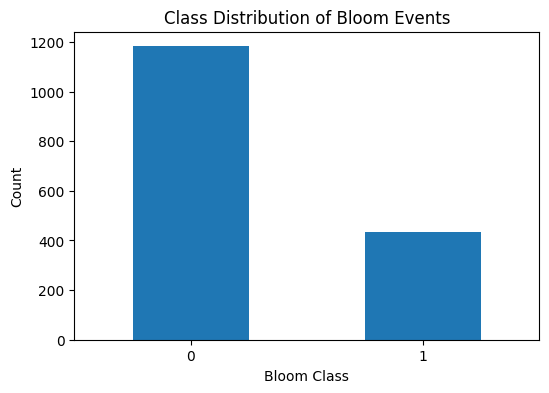

In [8]:
class_counts = df["bloom"].value_counts()
print(class_counts)
print(df["bloom"].value_counts(normalize=True))

plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")
plt.title("Class Distribution of Bloom Events")
plt.xlabel("Bloom Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Step 8. Check missing values

The predictor variables were checked for missing values before modeling. Confirming data completeness is important because missing values can interfere with model training and reduce interpretability.

In [9]:
print(X.isna().sum())

zos                0
salinity           0
water_temp         0
wind_direction     0
wind_speed         0
peace_discharge    0
peace_TN           0
peace_TP           0
dtype: int64


## Step 9. Explore variable relationships

A correlation matrix was used as an exploratory step to examine general relationships among environmental variables and Karenia brevis concentration. While correlation alone does not determine bloom occurrence, it helps identify patterns and supports the need for a nonlinear model.

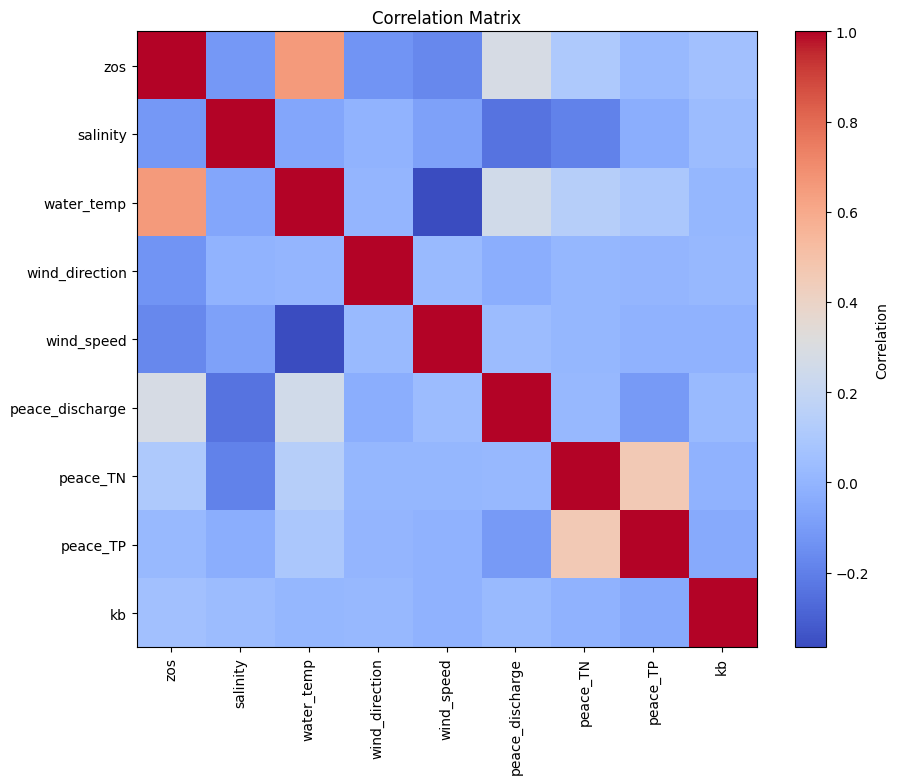

In [10]:
corr = df[features + ["kb"]].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

## Step 10. Split the data by time

The dataset was split chronologically, with the first 80% of observations used for training and the final 20% used for testing. A time-based split was chosen instead of a random split to preserve the temporal structure of the dataset and better simulate real-world bloom prediction.

In [11]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 1293
Testing rows: 324


## Step 11. Train the Random Forest classifier

A Random Forest classifier was used to predict whether harmful bloom conditions occur. This model was chosen because it can capture nonlinear relationships and interactions among environmental variables, which are common in ecological systems. The `class_weight="balanced"` setting was included to help account for any imbalance between bloom and non-bloom observations.

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## Step 12. Generate predictions

The trained model was used to predict bloom class labels for the test dataset. In addition to binary predictions, predicted probabilities for the bloom class were generated to support threshold-based evaluation and interpretation.

In [13]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

## Step 13. Model performance evaluation

The Random Forest classifier achieved an accuracy of approximately 56% and a ROC-AUC of 0.59. These values indicate that the model performs only slightly better than random classification and has limited ability to distinguish between bloom and non-bloom conditions.

Precision and recall for the bloom class were both below 0.50, indicating that the model struggles both to correctly identify bloom events and to avoid false positives. In particular, the relatively low recall suggests that a substantial proportion of true bloom events are not captured by the model.

Overall, these results suggest that while environmental variables provide some predictive signal, they are insufficient on their own to reliably predict harmful bloom occurrence in this dataset.

In [14]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.558641975308642
ROC-AUC: 0.5900802911046948

Classification Report:

              precision    recall  f1-score   support

           0       0.63      0.61      0.62       193
           1       0.46      0.48      0.47       131

    accuracy                           0.56       324
   macro avg       0.55      0.55      0.55       324
weighted avg       0.56      0.56      0.56       324



## Step 14. Confusion matrix interpretation

The confusion matrix provides a more detailed view of classification performance. The model correctly identifies a portion of both bloom and non-bloom observations, but also produces a substantial number of false positives and false negatives.

Notably, a significant number of bloom events are misclassified as non-bloom conditions. This low sensitivity limits the usefulness of the model for applications where detecting bloom events is critical. At the same time, the model also produces false positives, indicating that it sometimes predicts bloom conditions where none are present.

These results highlight the difficulty of predicting harmful algal blooms using environmental variables alone, and suggest that additional drivers or improved modeling approaches may be necessary.

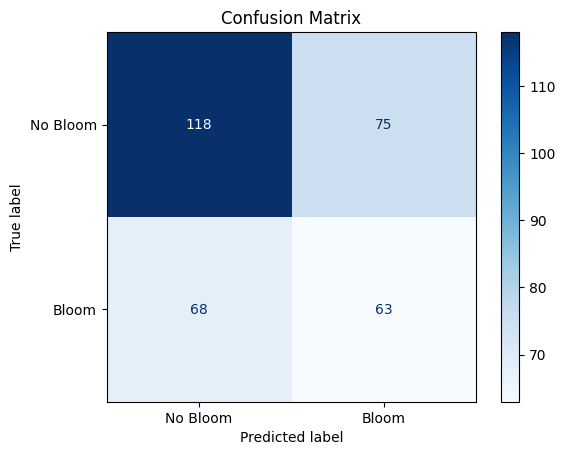

In [15]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Bloom", "Bloom"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## Step 15. ROC curve interpretation

The ROC curve lies slightly above the diagonal line, and the AUC value of 0.59 indicates weak discrimination between bloom and non-bloom conditions. This suggests that the model has limited ability to consistently separate the two classes across different probability thresholds.

While the model performs better than random guessing, the relatively low AUC indicates that its predictive capacity is not strong enough for reliable classification. This result reflects the complexity of bloom dynamics and the likely influence of additional unmeasured factors.

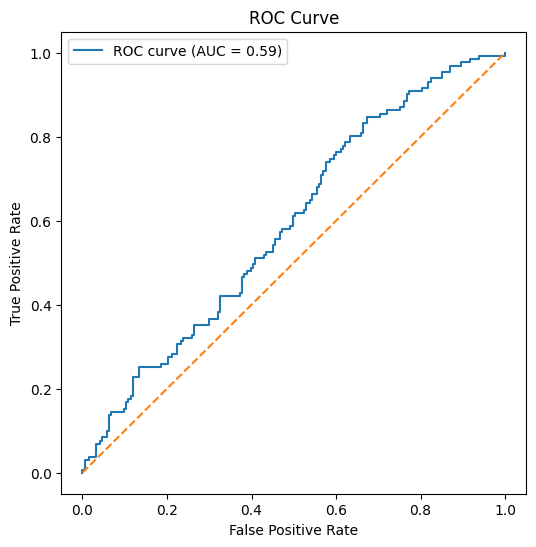

In [16]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Step 16. SHAP summary interpretation

The SHAP summary plot identifies the variables that most strongly influence the model’s predictions of bloom occurrence. Water temperature emerged as the most influential variable, followed by sea surface height, wind speed, and total phosphorus.

However, given the relatively weak predictive performance of the model, these results should be interpreted with caution. SHAP values reflect the internal behavior of the model rather than definitive causal relationships. Therefore, the importance of temperature and other physical variables may reflect patterns present in this specific dataset rather than generalizable ecological drivers.

The results suggest that physical environmental conditions may play an important role in shaping bloom occurrence, but they do not provide strong evidence that these variables alone are sufficient to explain bloom dynamics.

In [17]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

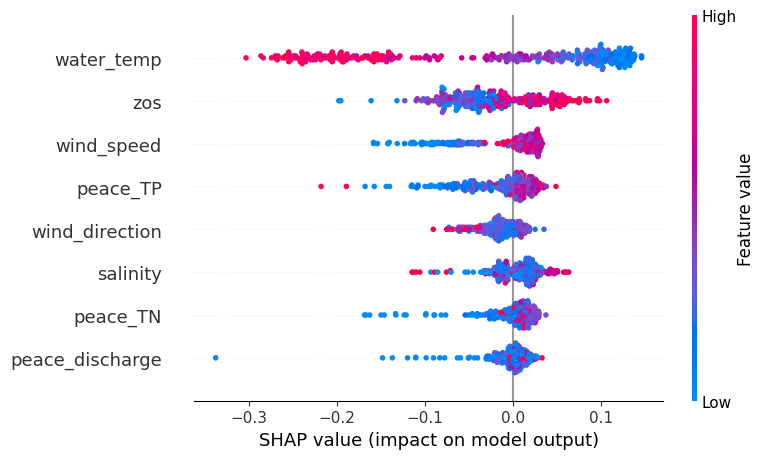

In [18]:
shap.summary_plot(shap_values[:, :, 1], X_test)

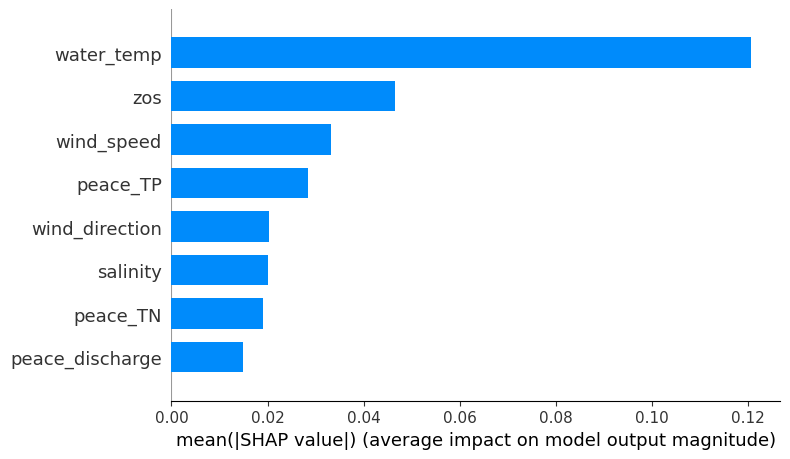

In [19]:
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar")

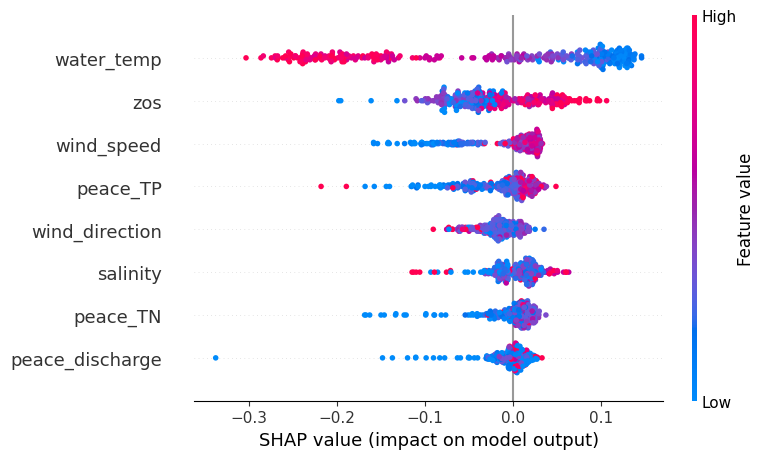

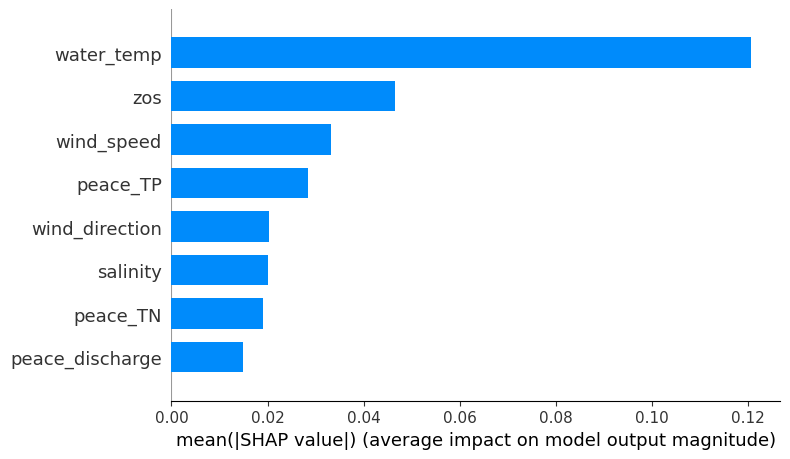

In [20]:
shap_class1 = shap_values[:, :, 1]

shap.summary_plot(shap_class1, X_test)
shap.summary_plot(shap_class1, X_test, plot_type="bar")

## Step 17. SHAP dependence plots

Dependence plots were used to examine how specific environmental variables influence the probability of a harmful bloom. These plots show both the direction of each variable's effect and how that effect may vary across observations.

### Salinity

The SHAP dependence plot for salinity shows a relatively weak and inconsistent relationship with bloom probability. While moderate salinity values appear to be associated with slightly higher predicted bloom likelihood, the overall effect is small and variable.

This suggests that salinity may influence bloom conditions indirectly, but it is not a dominant driver in the model. The variability in the relationship also indicates that salinity likely interacts with other environmental factors rather than acting independently.

### Total Nitrogen (peace_TN)

Total nitrogen shows a generally positive relationship with predicted bloom probability, with higher nitrogen values tending to push predictions toward bloom conditions. This aligns with the established role of nutrient enrichment in promoting algal growth.

However, the strength of this relationship is moderate and not consistently strong across all observations. Given the overall model performance, this result should be interpreted as indicative of a partial influence rather than a dominant controlling factor.

### Total Phosphorus (peace_TP)

Total phosphorus exhibits a clearer pattern than nitrogen, with moderate phosphorus concentrations associated with increased bloom probability. This suggests that phosphorus may play a meaningful role in bloom development within this dataset.

However, the relationship is not strictly linear and becomes less consistent at higher concentrations. This may reflect threshold effects or interactions with other environmental variables. As with other predictors, the interpretation is limited by the overall performance of the model.

### Discharge (peace_discharge)

Discharge shows a predominantly negative relationship with bloom probability, with higher discharge values generally associated with reduced likelihood of bloom conditions. This pattern is consistent with the idea that increased freshwater input can dilute algal concentrations or disrupt favorable conditions for bloom formation.

However, the effect is relatively weak and concentrated at lower discharge values, indicating that discharge alone is not a strong predictor of bloom occurrence. The influence of discharge is likely context-dependent and interacts with nutrient transport and coastal processes.

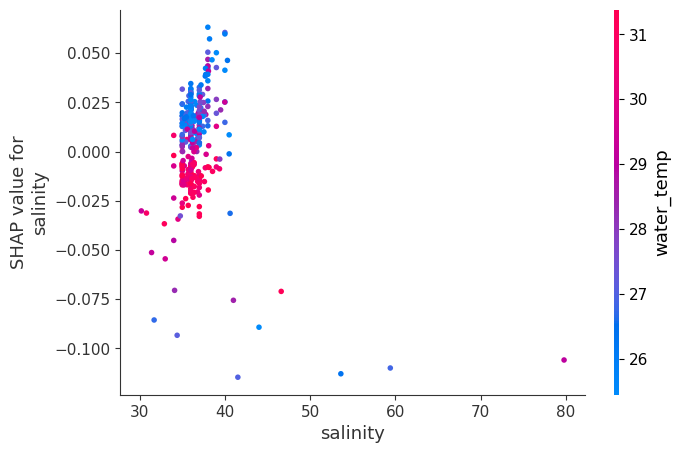

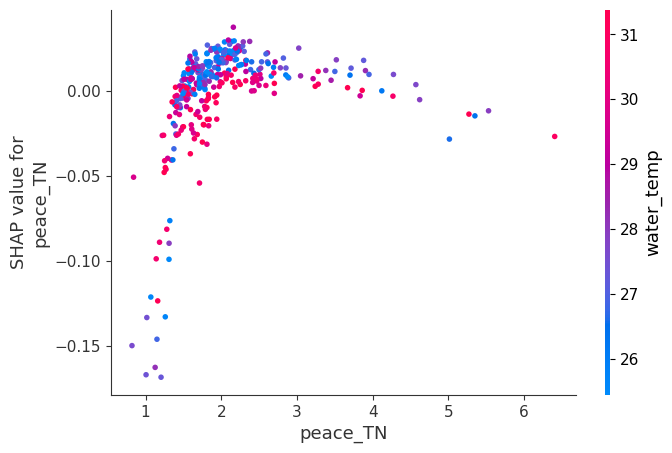

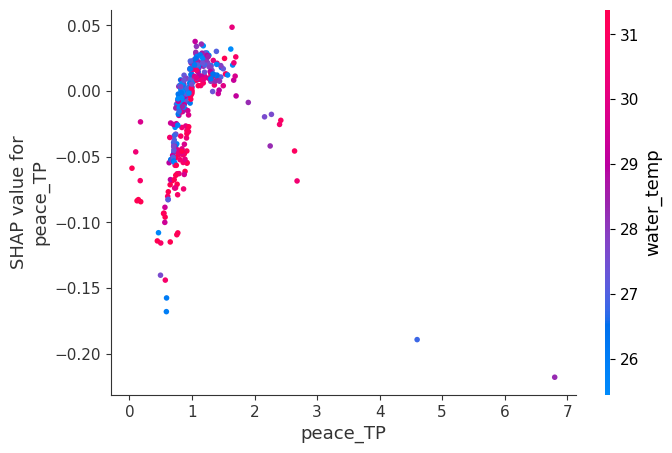

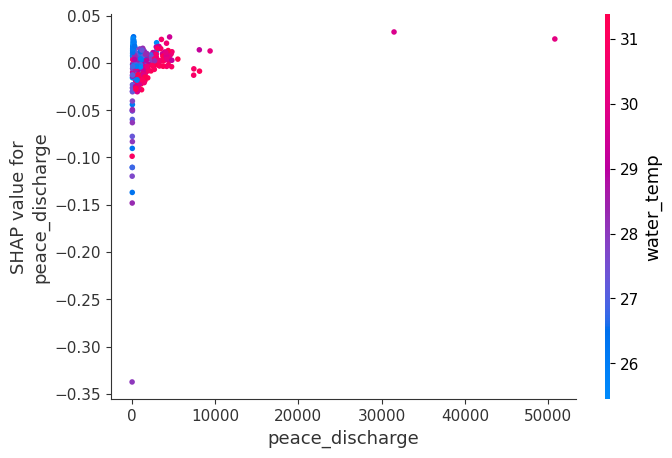

In [21]:
# Use whichever indexing format works for your SHAP output
shap_class1 = shap_values[:, :, 1]   # or shap_values[1]

shap.dependence_plot("salinity", shap_class1, X_test)
shap.dependence_plot("peace_TN", shap_class1, X_test)
shap.dependence_plot("peace_TP", shap_class1, X_test)
shap.dependence_plot("peace_discharge", shap_class1, X_test)

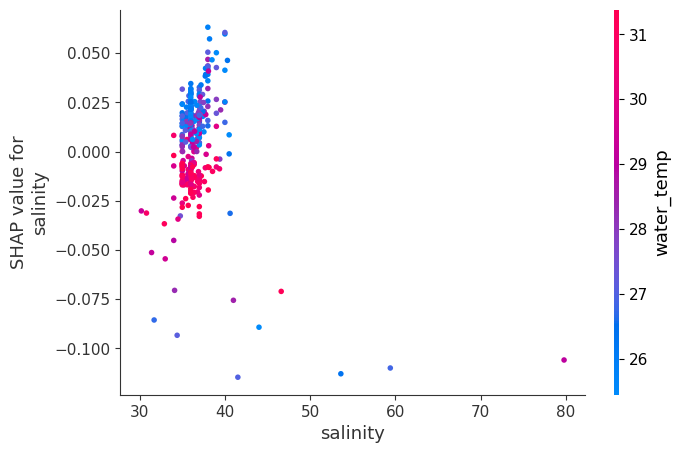

In [22]:
shap.dependence_plot("salinity", shap_class1, X_test)


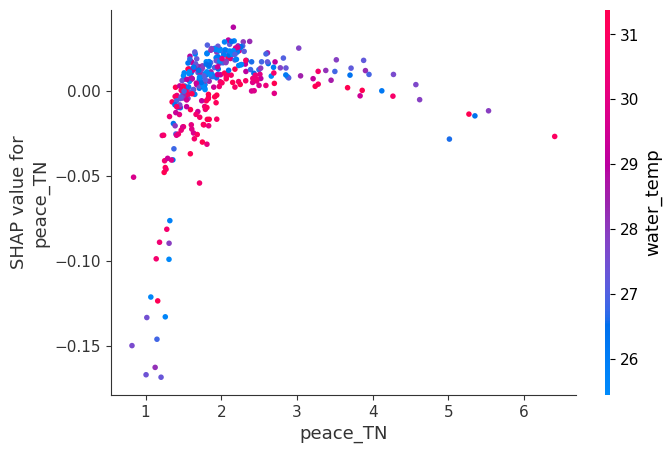

In [36]:
shap.dependence_plot("peace_TN", shap_class1, X_test)


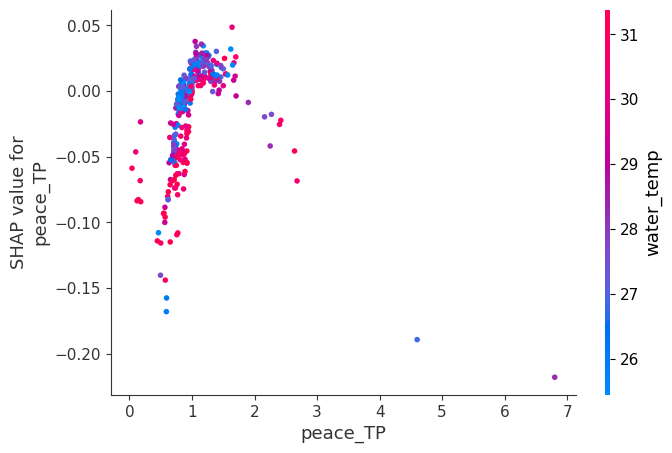

In [35]:
shap.dependence_plot("peace_TP", shap_class1, X_test)


## Step 18. Model refinement and improvement

The baseline Random Forest classifier showed limited predictive ability, indicating that additional refinement was needed. To improve performance, three targeted adjustments were explored.

First, the classification threshold was adjusted to prioritize detection of bloom events. In harmful algal bloom applications, missing a true bloom event can be more problematic than issuing a false alarm, so recall is an especially important metric.

Second, lagged environmental variables were added to account for temporal dynamics. Bloom development is not instantaneous, and prior environmental conditions may be more informative than conditions measured only in the same week.

Third, class imbalance was addressed using oversampling so that bloom events were more strongly represented during model training.

These steps were intended to test whether predictive performance could be improved while maintaining an interpretable modeling framework.

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score

# Predicted probabilities from the baseline model
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Baseline threshold = 0.50
y_pred_05 = (y_prob >= 0.50).astype(int)

print("Baseline threshold = 0.50")
print("Accuracy:", accuracy_score(y_test, y_pred_05))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred_05))

Baseline threshold = 0.50
Accuracy: 0.558641975308642
ROC-AUC: 0.5900802911046948
              precision    recall  f1-score   support

           0       0.63      0.61      0.62       193
           1       0.46      0.48      0.47       131

    accuracy                           0.56       324
   macro avg       0.55      0.55      0.55       324
weighted avg       0.56      0.56      0.56       324



### Threshold tuning

The default probability threshold for classification is 0.50, meaning that observations are classified as bloom events only when the predicted bloom probability is at least 50%. However, in bloom monitoring applications, it can be more important to detect as many real bloom events as possible, even if that increases the number of false positives.

To test this, the classification threshold was lowered. This does not change the model itself, but changes how predicted probabilities are converted into bloom or non-bloom classifications.

In [24]:
# Adjusted threshold
threshold = 0.30
y_pred_03 = (y_prob >= threshold).astype(int)

print(f"Adjusted threshold = {threshold}")
print("Accuracy:", accuracy_score(y_test, y_pred_03))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred_03))

Adjusted threshold = 0.3
Accuracy: 0.5493827160493827
ROC-AUC: 0.5900802911046948
              precision    recall  f1-score   support

           0       0.71      0.41      0.52       193
           1       0.46      0.75      0.57       131

    accuracy                           0.55       324
   macro avg       0.59      0.58      0.55       324
weighted avg       0.61      0.55      0.54       324



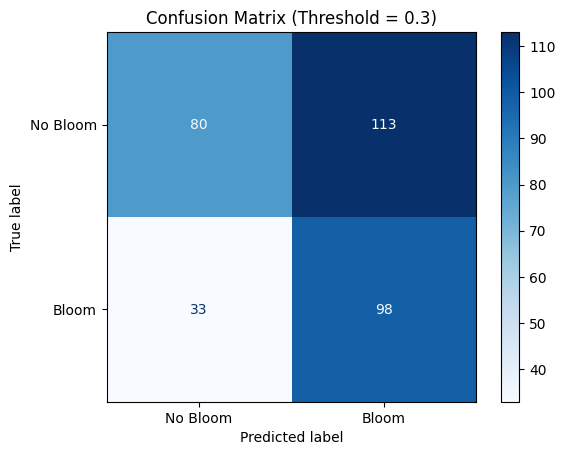

In [25]:
cm = confusion_matrix(y_test, y_pred_03)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Bloom", "Bloom"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (Threshold = {threshold})")
plt.show()

### Interpretation of threshold tuning

Lowering the classification threshold increases the number of observations classified as bloom events. This often improves recall because the model captures more true bloom cases, although it may also reduce precision by producing more false positives.

This adjustment can improve practical usefulness when the cost of missing a bloom event is greater than the cost of a false alarm. In this study, threshold tuning was used to test whether bloom detection could be improved without retraining the model.

Lowering the threshold improved the model's ability to detect bloom events, indicating that some bloom information was already present in the predicted probabilities but was not being captured under the default threshold.

Lowering the threshold produced only modest improvement, suggesting that the model's underlying class separation remains weak even when classification criteria are relaxed.

### Adding lagged environmental variables

Harmful algal blooms develop over time and are often influenced by environmental conditions from previous weeks rather than only current-week measurements. To account for this temporal dependence, lagged versions of selected predictor variables were added.

Lag variables allow the model to incorporate short-term environmental memory, which may improve bloom prediction by capturing delayed system responses.

In [26]:
df_lag = df.copy()

# Add 1-week lag variables
df_lag["TN_lag1"] = df_lag["peace_TN"].shift(1)
df_lag["TP_lag1"] = df_lag["peace_TP"].shift(1)
df_lag["temp_lag1"] = df_lag["water_temp"].shift(1)
df_lag["discharge_lag1"] = df_lag["peace_discharge"].shift(1)
df_lag["salinity_lag1"] = df_lag["salinity"].shift(1)

# Remove first row(s) with missing lag values
df_lag = df_lag.dropna().reset_index(drop=True)

In [27]:
lag_features = [
    "zos",
    "salinity",
    "water_temp",
    "wind_direction",
    "wind_speed",
    "peace_discharge",
    "peace_TN",
    "peace_TP",
    "TN_lag1",
    "TP_lag1",
    "temp_lag1",
    "discharge_lag1",
    "salinity_lag1"
]

X_lag = df_lag[lag_features]
y_lag = df_lag["bloom"]

In [28]:
split_index_lag = int(len(df_lag) * 0.8)

X_train_lag = X_lag.iloc[:split_index_lag]
X_test_lag = X_lag.iloc[split_index_lag:]

y_train_lag = y_lag.iloc[:split_index_lag]
y_test_lag = y_lag.iloc[split_index_lag:]

In [29]:
rf_lag = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf_lag.fit(X_train_lag, y_train_lag)

y_prob_lag = rf_lag.predict_proba(X_test_lag)[:, 1]
y_pred_lag = (y_prob_lag >= 0.30).astype(int)

print("Lagged model performance")
print("Accuracy:", accuracy_score(y_test_lag, y_pred_lag))
print("ROC-AUC:", roc_auc_score(y_test_lag, y_prob_lag))
print(classification_report(y_test_lag, y_pred_lag))

Lagged model performance
Accuracy: 0.5679012345679012
ROC-AUC: 0.6188743424435391
              precision    recall  f1-score   support

           0       0.73      0.44      0.55       193
           1       0.48      0.76      0.59       131

    accuracy                           0.57       324
   macro avg       0.60      0.60      0.57       324
weighted avg       0.63      0.57      0.56       324



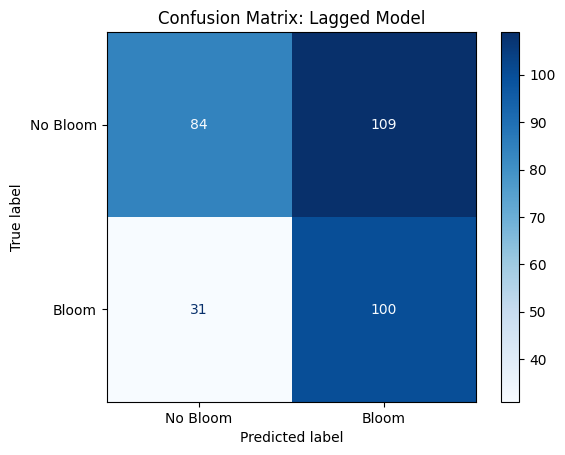

In [30]:
cm = confusion_matrix(y_test_lag, y_pred_lag)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Bloom", "Bloom"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Lagged Model")
plt.show()

### Interpretation of lagged variables

Including lagged variables tests whether bloom occurrence is influenced by prior environmental conditions. If performance improves, this suggests that short-term environmental memory is important and that bloom formation depends not only on same-week measurements but also on preceding nutrient, temperature, discharge, and salinity conditions.

If performance does not improve substantially, this indicates either that a one-week lag is insufficient to capture bloom dynamics or that additional ecological and physical variables are needed.

### Addressing class imbalance with oversampling

Bloom events are often less common than non-bloom observations, which can make it harder for the classifier to learn patterns associated with the bloom class. To address this issue, synthetic minority oversampling was applied to the training data.

This method increases representation of the bloom class during model training, which can improve recall and the model's sensitivity to bloom events.

In [31]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_lag, y_train_lag)

print("Original training class counts:")
print(y_train_lag.value_counts())

print("\nResampled training class counts:")
print(pd.Series(y_train_sm).value_counts())

Original training class counts:
bloom
0    988
1    304
Name: count, dtype: int64

Resampled training class counts:
bloom
0    988
1    988
Name: count, dtype: int64


In [32]:
rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf_smote.fit(X_train_sm, y_train_sm)

y_prob_smote = rf_smote.predict_proba(X_test_lag)[:, 1]
y_pred_smote = (y_prob_smote >= 0.30).astype(int)

print("Lagged + SMOTE model performance")
print("Accuracy:", accuracy_score(y_test_lag, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test_lag, y_prob_smote))
print(classification_report(y_test_lag, y_pred_smote))

Lagged + SMOTE model performance
Accuracy: 0.5246913580246914
ROC-AUC: 0.6444646600482538
              precision    recall  f1-score   support

           0       0.75      0.31      0.43       193
           1       0.45      0.85      0.59       131

    accuracy                           0.52       324
   macro avg       0.60      0.58      0.51       324
weighted avg       0.63      0.52      0.50       324



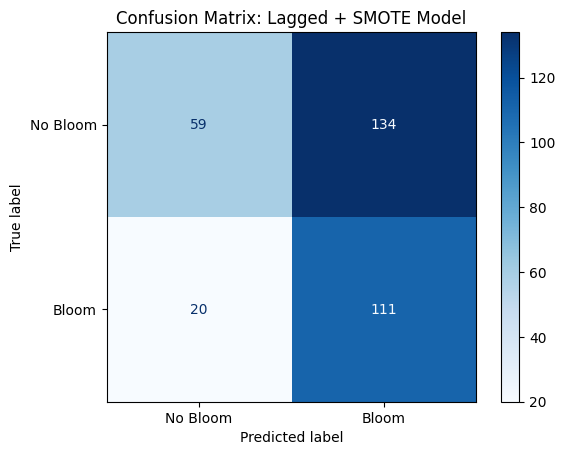

In [33]:
cm = confusion_matrix(y_test_lag, y_pred_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Bloom", "Bloom"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Lagged + SMOTE Model")
plt.show()

### Interpretation of oversampling

Oversampling improved class representation during training by increasing the presence of bloom cases. If recall improves, this suggests that the original model was limited in part by class imbalance and underexposure to bloom examples.

However, oversampling can also increase false positives, so improved bloom detection must be weighed against reduced precision. For this reason, model performance should be assessed using multiple metrics rather than accuracy alone.

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame([
    {
        "Model": "Baseline (0.50 threshold)",
        "Accuracy": accuracy_score(y_test, y_pred_05),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred_05, zero_division=0),
        "Recall": recall_score(y_test, y_pred_05, zero_division=0),
        "F1": f1_score(y_test, y_pred_05, zero_division=0)
    },
    {
        "Model": "Baseline (0.30 threshold)",
        "Accuracy": accuracy_score(y_test, y_pred_03),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred_03, zero_division=0),
        "Recall": recall_score(y_test, y_pred_03, zero_division=0),
        "F1": f1_score(y_test, y_pred_03, zero_division=0)
    },
    {
        "Model": "Lagged model (0.30 threshold)",
        "Accuracy": accuracy_score(y_test_lag, y_pred_lag),
        "ROC_AUC": roc_auc_score(y_test_lag, y_prob_lag),
        "Precision": precision_score(y_test_lag, y_pred_lag, zero_division=0),
        "Recall": recall_score(y_test_lag, y_pred_lag, zero_division=0),
        "F1": f1_score(y_test_lag, y_pred_lag, zero_division=0)
    },
    {
        "Model": "Lagged + SMOTE (0.30 threshold)",
        "Accuracy": accuracy_score(y_test_lag, y_pred_smote),
        "ROC_AUC": roc_auc_score(y_test_lag, y_prob_smote),
        "Precision": precision_score(y_test_lag, y_pred_smote, zero_division=0),
        "Recall": recall_score(y_test_lag, y_pred_smote, zero_division=0),
        "F1": f1_score(y_test_lag, y_pred_smote, zero_division=0)
    }
])

results

,Model,Accuracy,ROC_AUC,Precision,Recall,F1
0,Baseline (0.50 threshold),0.558642,0.590080,0.456522,0.480916,0.468401
1,Baseline (0.30 threshold),0.549383,0.590080,0.464455,0.748092,0.573099
2,Lagged model (0.30 threshold),0.567901,0.618874,0.478469,0.763359,0.588235
3,Lagged + SMOTE (0.30 threshold),0.524691,0.644465,0.453061,0.847328,0.590426


### Model comparison

Comparing the baseline and refined models allows evaluation of whether changes in threshold, lagged predictors, and class balancing produce meaningful improvements in predictive ability.

Particular attention is given to recall, since improved detection of true bloom events is often more important than maximizing overall accuracy in harmful algal bloom applications.

## Interpretation of model refinement

Model refinement produced meaningful but limited improvements in predictive performance. Lowering the classification threshold substantially increased recall, indicating that the baseline model contained bloom-related signal that was not captured under the default threshold.

The addition of lagged variables resulted in improved ROC-AUC and F1-score, suggesting that bloom occurrence is influenced by prior environmental conditions and that incorporating temporal structure enhances model performance.

Oversampling further increased recall to approximately 0.85, demonstrating that class imbalance was a major limitation of the baseline model. However, this improvement came at the cost of reduced precision and overall accuracy, reflecting an increase in false positive predictions.

Overall, these refinements improved the model’s ability to detect bloom events but did not substantially improve overall predictive accuracy. This suggests that while environmental variables contain useful information, harmful algal bloom dynamics are influenced by additional factors not captured in the dataset.

## Overall interpretation

The classification model demonstrates limited predictive ability, indicating that environmental variables alone are not sufficient to reliably predict harmful algal bloom occurrence in this dataset. While the model captures some structure in the data, its performance suggests that important drivers of bloom dynamics are either missing or not adequately represented.

SHAP analysis provides insight into how the model uses available variables, highlighting the importance of temperature and physical environmental conditions. However, these findings should not be interpreted as definitive ecological conclusions. Instead, they suggest potential relationships that warrant further investigation.

Overall, the results emphasize the complexity of harmful algal bloom systems, which are influenced by multiple interacting factors including nutrient availability, hydrodynamics, biological processes, and environmental variability. Future work should incorporate additional variables and more advanced modeling approaches to improve predictive performance.

ChatGPT (OpenAI, 2025) was used as a support tool for code structuring, debugging, and explanation of machine learning workflow. All data processing decisions, model design choices, interpretations, and final conclusions were independently reviewed and validated.